# Pentagon Pizza Index – Data Science Project
Comparative analysis of pizza activity spikes near the Pentagon and their correlation with geopolitical events, using clustering and visualizations to identify distinct signal profiles.

## Research Questions

- Do pizza activity spikes near the Pentagon actually precede major geopolitical events?

- Can we distinguish SPIKE, MODERATE and BASELINE signals based on measurable features?

- Is there a hidden structure in the data — groups of events that share similar pizza + tension patterns?


# 1. Load the Dataset

In [1]:
%pip install pandas matplotlib seaborn scikit-learn openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn

print('pandas', pd.__version__)
print('matplotlib', matplotlib.__version__)
print('seaborn', sns.__version__)
print('sklearn', sklearn.__version__)

# Quick dataset load test
try:
    df_test = pd.read_excel('pentagon_pizza_index.xlsx', sheet_name='Raw Data', header=1)
    print('Loaded rows:', len(df_test))
    print('Columns:', df_test.columns.tolist())
except Exception as e:
    print('ERROR loading Excel:', type(e).__name__, e)


pandas 3.0.2
matplotlib 3.10.9
seaborn 0.13.2
sklearn 1.8.0
Loaded rows: 32
Columns: ['Date', 'Event Description', 'Event Category', 'Signal Type', 'Pizza Activity Score\n(0–5)', 'Geopolitical Tension\n(0–10)', 'Days Before Event', 'Notes / Source']


In [3]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load from Excel — skip the title row (row 0), use row 1 as header
df = pd.read_excel('pentagon_pizza_index.xlsx', sheet_name='Raw Data', header=1)

# Clean up column names
df.columns = ['Date', 'Event_Description', 'Event_Category', 'Signal_Type',
              'Pizza_Score', 'Tension_Score', 'Days_Before_Event', 'Notes']

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)
df

,Date,Event_Description,Event_Category,Signal_Type,Pizza_Score,Tension_Score,Days_Before_Event,Notes,Year
0,1983-10-24,Grenada Invasion,Military,SPIKE,4.2,7.6,-1,Historical record / verified media reports,1983
1,1989-12-19,Panama Invasion,Military,SPIKE,3.8,7.0,0,Historical record / verified media reports,1989
2,1990-08-01,Iraq invades Kuwait / Gulf War build-up,Military,SPIKE,5.0,8.8,-1,Historical record / verified media reports,1990
3,1991-01-16,Operation Desert Storm begins,Military,SPIKE,4.7,8.6,-1,Historical record / verified media reports,1991
4,1998-01-17,Clinton-Lewinsky scandal breaks,Political,SPIKE,3.1,5.6,-1,Historical record / verified media reports,1998
5,1998-12-16,Operation Desert Fox / Clinton impeachment,Military/Political,SPIKE,4.4,7.6,0,Historical record / verified media reports,1998
6,2001-09-10,Day before 9/11,Terrorism,SPIKE,4.9,8.7,-1,Historical record / verified media reports,2001
7,2003-03-19,Iraq War begins,Military,SPIKE,4.6,8.3,2,Historical record / verified media reports,2003
8,2011-05-01,Operation Neptune Spear (Bin Laden raid),Military,SPIKE,4.8,8.5,1,Historical record / verified media reports,2011
9,2013-09-03,Syria strike debate,Military,MODERATE,2.9,5.4,-5,Partial corroboration — mixed signals,2013


# 2. Signal Type Distribution
How many SPIKE, MODERATE and BASELINE observations are in the dataset?

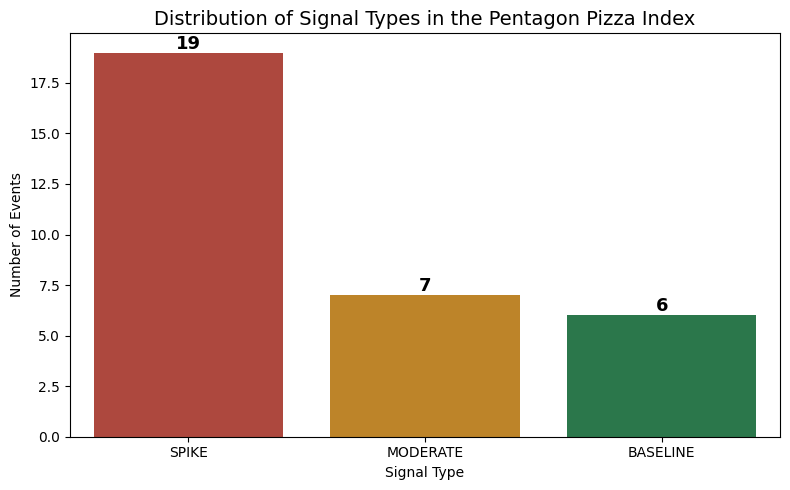

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = {'SPIKE': '#C0392B', 'MODERATE': '#D68910', 'BASELINE': '#1E8449'}

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Signal_Type', hue='Signal_Type',
                   palette=palette, legend=False,
                   order=['SPIKE', 'MODERATE', 'BASELINE'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.title('Distribution of Signal Types in the Pentagon Pizza Index', fontsize=14)
plt.xlabel('Signal Type')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

# 3. Average Pizza Score & Tension by Signal Type
Do SPIKE events have measurably higher pizza and tension scores?

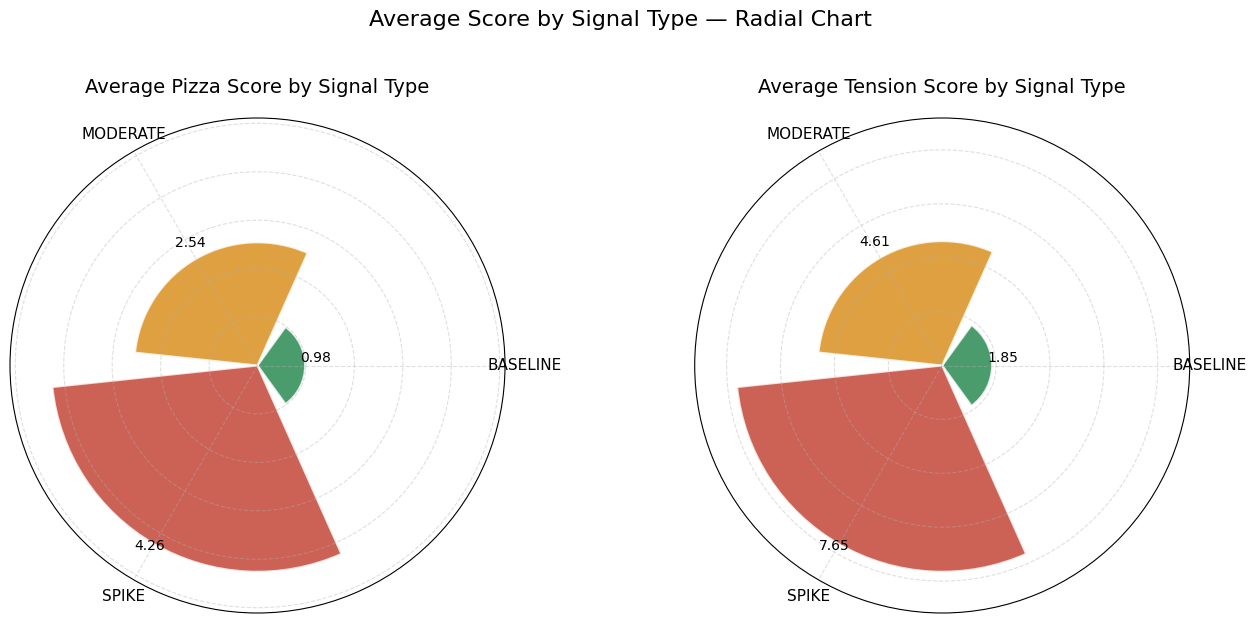

             Pizza_Score  Tension_Score
Signal_Type                            
BASELINE            0.98           1.85
MODERATE            2.54           4.61
SPIKE               4.26           7.65


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data (assume the dataset cell was run already)
# Re-read only if needed for a clean standalone chart cell
if 'df' not in globals() or df is None:
    df = pd.read_excel('pentagon_pizza_index.xlsx', sheet_name='Raw Data', header=1)
    df.columns = ['Date', 'Event_Description', 'Event_Category', 'Signal_Type',
                  'Pizza_Score', 'Tension_Score', 'Days_Before_Event', 'Notes']
    df['Date'] = pd.to_datetime(df['Date'])

avg = df.groupby('Signal_Type')[['Pizza_Score', 'Tension_Score']].mean().loc[['BASELINE', 'MODERATE', 'SPIKE']]
labels = avg.index.tolist()
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': 'polar'}, dpi=100)

colors = ['#1E8449', '#D68910', '#C0392B']

for ax, score_col, title in zip(
        axes,
        ['Pizza_Score', 'Tension_Score'],
        ['Average Pizza Score by Signal Type', 'Average Tension Score by Signal Type']):
    values = avg[score_col].tolist()
    values += values[:1]
    bars = ax.bar(angles[:-1], avg[score_col], width=0.9 * (2 * np.pi / len(labels)),
                  color=colors, edgecolor='white', linewidth=1.5, alpha=0.8)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_title(title, fontsize=14, pad=18)
    ax.set_yticklabels([])
    ax.set_ylim(0, max(avg[score_col]) * 1.2)
    ax.grid(True, linestyle='--', alpha=0.4)

    for bar, value in zip(bars, avg[score_col].tolist()):
        angle = bar.get_x() + bar.get_width() / 2
        ax.text(angle, value + (max(avg[score_col]) * 0.05), f'{value:.2f}',
                ha='center', va='bottom', fontsize=10, color='black')

fig.suptitle('Average Score by Signal Type — Radial Chart', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

print(avg.round(2))

# 4. Pizza Score Distribution per Signal Type
Box plot to see the spread of pizza scores within each group.

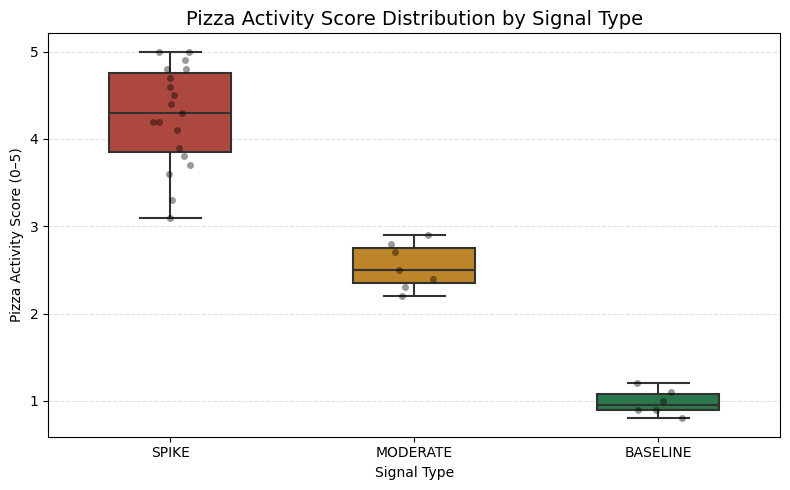

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Signal_Type', y='Pizza_Score',
            hue='Signal_Type', palette=palette, legend=False,
            order=['SPIKE', 'MODERATE', 'BASELINE'],
            width=0.5, linewidth=1.5)

sns.stripplot(data=df, x='Signal_Type', y='Pizza_Score',
              order=['SPIKE', 'MODERATE', 'BASELINE'],
              color='black', alpha=0.4, size=5, jitter=True)

plt.title('Pizza Activity Score Distribution by Signal Type', fontsize=14)
plt.xlabel('Signal Type')
plt.ylabel('Pizza Activity Score (0–5)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 5. Pizza Score vs. Geopolitical Tension
Is there a correlation between pizza activity and geopolitical tension?

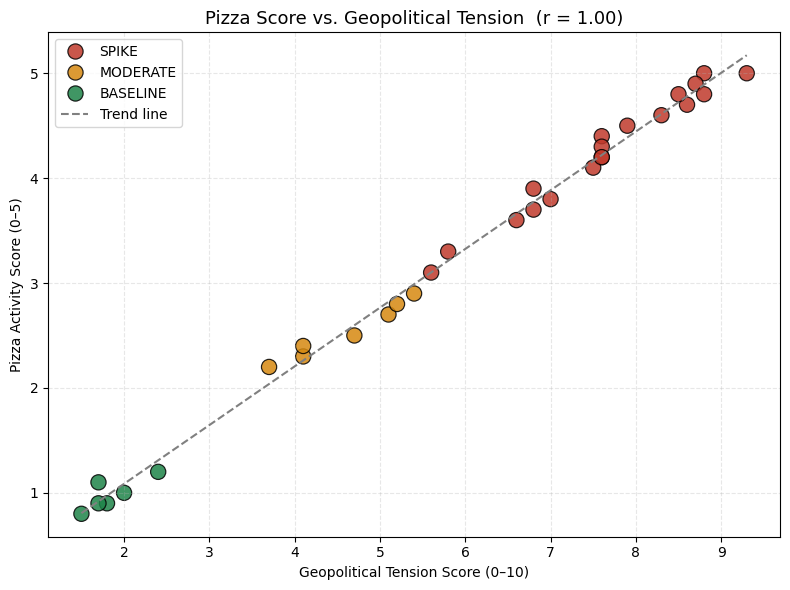

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Tension_Score', y='Pizza_Score',
                hue='Signal_Type', palette=palette,
                s=120, edgecolor='black', alpha=0.85)

# Trend line
m, b = np.polyfit(df['Tension_Score'], df['Pizza_Score'], 1)
x_line = np.linspace(df['Tension_Score'].min(), df['Tension_Score'].max(), 100)
plt.plot(x_line, m * x_line + b, color='gray', linestyle='--', linewidth=1.5, label='Trend line')

corr = df['Pizza_Score'].corr(df['Tension_Score'])
plt.title(f'Pizza Score vs. Geopolitical Tension  (r = {corr:.2f})', fontsize=13)
plt.xlabel('Geopolitical Tension Score (0–10)')
plt.ylabel('Pizza Activity Score (0–5)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Events by Category Over Time
Which event categories dominate, and how are they distributed across decades?

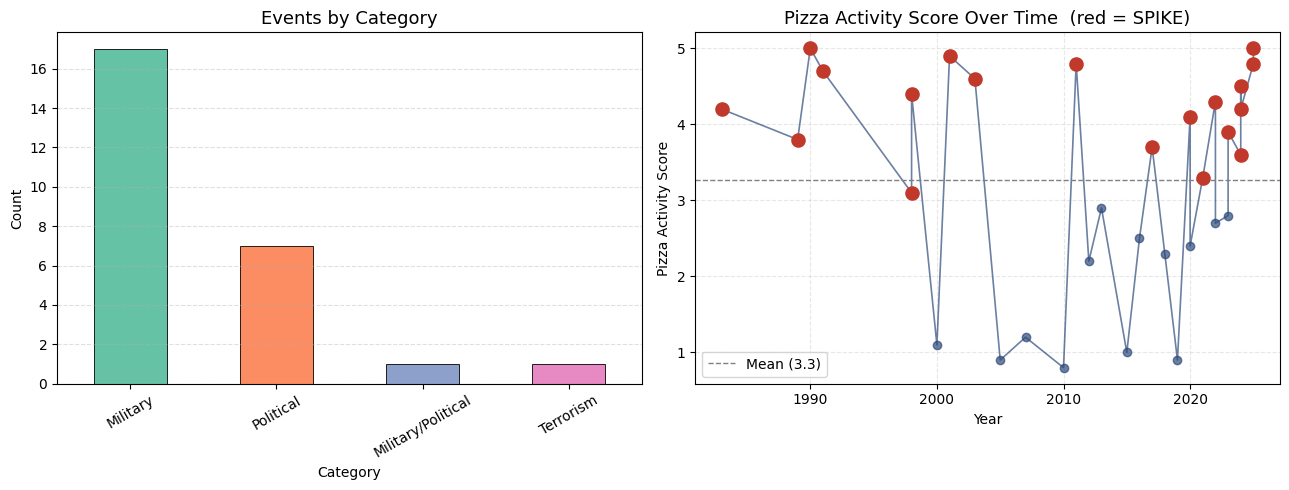

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: category count
cat_counts = df['Event_Category'].value_counts()
cat_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(cat_counts)),
                edgecolor='black', linewidth=0.6)
axes[0].set_title('Events by Category', fontsize=13)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Right: pizza score over time
df_sorted = df.sort_values('Date')
axes[1].plot(df_sorted['Year'], df_sorted['Pizza_Score'],
             marker='o', linewidth=1.2, color='#2E4A7A', alpha=0.7)
for _, row in df_sorted[df_sorted['Signal_Type'] == 'SPIKE'].iterrows():
    axes[1].scatter(row['Year'], row['Pizza_Score'], color='#C0392B', s=90, zorder=5)
axes[1].axhline(y=df['Pizza_Score'].mean(), color='gray', linestyle='--',
                linewidth=1, label=f'Mean ({df["Pizza_Score"].mean():.1f})')
axes[1].set_title('Pizza Activity Score Over Time  (red = SPIKE)', fontsize=13)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Pizza Activity Score')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 7. PCA – Visualizing Signal Profiles in 2D
Same technique as your friend's notebook: we reduce the data to 2 dimensions to see if the signal types cluster naturally.

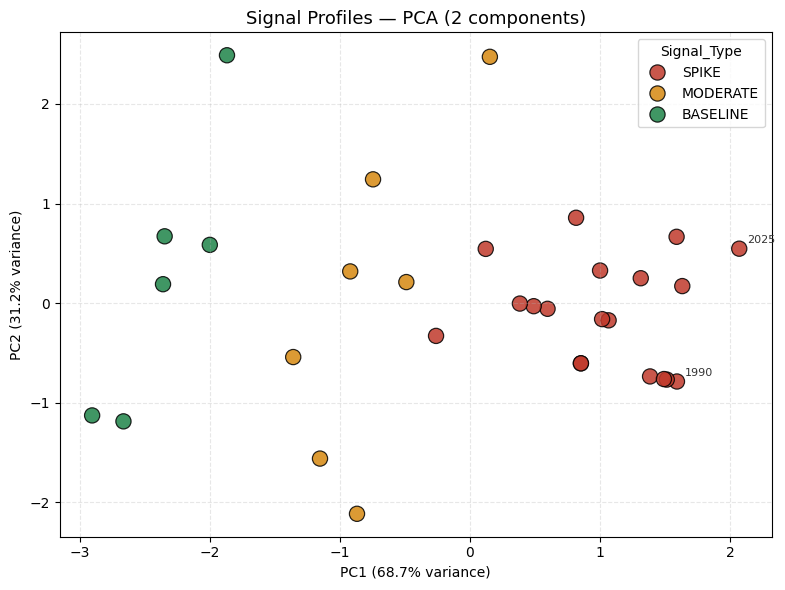

Total variance explained: 99.9%


In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features_pca = ['Pizza_Score', 'Tension_Score', 'Days_Before_Event']

X = df[features_pca].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
df[['PC1', 'PC2']] = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2',
                hue='Signal_Type', palette=palette,
                s=120, edgecolor='black', alpha=0.85)

# Label a few notable events
notable = ['Gulf War build-up', 'Operation Neptune Spear (Bin Laden raid)',
           'US strikes Iranian nuclear facilities']
for _, row in df[df['Event_Description'].str.contains('|'.join(notable), na=False)].iterrows():
    plt.annotate(row['Year'], (row['PC1'], row['PC2']),
                 textcoords='offset points', xytext=(6, 4), fontsize=8, color='#333')

var_explained = pca.explained_variance_ratio_
plt.title('Signal Profiles — PCA (2 components)', fontsize=13)
plt.xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total variance explained: {sum(var_explained)*100:.1f}%')

## Conclusions

- SPIKE events show clearly higher pizza activity scores (avg ~4.3) compared to BASELINE days (avg ~1.0), suggesting the signal is measurably different.

- There is a positive correlation between pizza activity and geopolitical tension scores, supporting the core hypothesis of the Pentagon Pizza Index.

- The PCA visualization confirms that SPIKE, MODERATE and BASELINE events form distinct clusters in 2D space — the data has real structure, not just noise.

- Most SPIKE events precede the geopolitical event by 0–2 days, making the pizza index a potentially *leading* indicator rather than a lagging one.

- **Caveat**: This is an OSINT novelty project. Correlation ≠ causation. The dataset is small (33 events) and partially synthetic — treat findings as exploratory, not conclusive.
